# Mount Google Drive to save the trained model

In [ ]:
# Mount Google Drive to save the trained model
from google.colab import drive
drive.mount('/content/drive')

print(" Google Drive mounted!")

Mounted at /content/drive
 Google Drive mounted!


# Install required packages

In [ ]:
# Install required packages
!pip install -q pandas scikit-learn numpy matplotlib seaborn joblib

print("All packages installed!")

All packages installed!


# Setup and Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Load the dataset
df = pd.read_csv('crop_dataset.csv')

# Display the first few rows and column names to verify
print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (1500, 23)


,crop_name,soil_type,season,temp_min,temp_max,ph_min,ph_max,rainfall_min,rainfall_max,water_need,...,altitude_min,altitude_max,fertilizer_n,fertilizer_p,fertilizer_k,yield_ton_per_ha,profit_usd_per_ha,difficulty_level,country,location_field
0,Rice (Aus),Clay,Summer,21,37,5.0,7.3,85,187,High,...,0,500,120,60,60,3.10,840,Easy,India,Punjab
1,Rice (Aus),Clay,Summer,21,38,5.2,7.7,98,184,High,...,0,500,120,60,60,3.29,789,Easy,Nepal,Ilam
2,Barley,Peaty,Spring,8,24,6.2,7.6,34,54,Low,...,500,1500,80,40,40,2.97,578,Medium,Nepal,Gulmi
3,Tea,Silty,Autumn,9,30,4.5,5.5,185,405,High,...,500,2000,120,60,60,1.89,1773,Medium,India,Himachal Pradesh
4,Apple (Mustang),Silty,Autumn,7,26,5.6,6.9,67,105,Medium,...,2000,3500,50,30,70,8.81,3669,Hard,Nepal,Sunsari


In [ ]:
df.tail()


,crop_name,soil_type,season,temp_min,temp_max,ph_min,ph_max,rainfall_min,rainfall_max,water_need,...,altitude_min,altitude_max,fertilizer_n,fertilizer_p,fertilizer_k,yield_ton_per_ha,profit_usd_per_ha,difficulty_level,country,location_field
1495,Horse Gram,Laterite,Monsoon,18,33,5.7,7.6,47,62,Low,...,300,1000,40,20,25,0.94,337,Easy,Nepal,Gulmi
1496,Muskmelon,Laterite,Autumn,24,37,6.0,7.7,36,97,Medium,...,200,800,90,45,90,20.66,1860,Easy,Nepal,Bara
1497,Radish,Laterite,Autumn,9,23,6.2,7.7,33,69,Medium,...,200,800,80,40,60,17.66,1392,Easy,Nepal,Ilam
1498,Muskmelon,Red,Winter,26,34,5.8,7.3,55,81,Medium,...,200,800,90,45,90,20.91,2051,Easy,Nepal,Bara
1499,Rice (Basmati),Laterite,Monsoon,20,41,5.9,7.5,78,165,Medium,...,300,800,100,50,50,3.03,1282,Medium,India,Maharashtra


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   crop_name          1500 non-null   object 
 1   soil_type          1500 non-null   object 
 2   season             1500 non-null   object 
 3   temp_min           1500 non-null   int64  
 4   temp_max           1500 non-null   int64  
 5   ph_min             1500 non-null   float64
 6   ph_max             1500 non-null   float64
 7   rainfall_min       1500 non-null   int64  
 8   rainfall_max       1500 non-null   int64  
 9   water_need         1500 non-null   object 
 10  duration_days      1500 non-null   int64  
 11  humidity_min       1500 non-null   int64  
 12  humidity_max       1500 non-null   int64  
 13  altitude_min       1500 non-null   int64  
 14  altitude_max       1500 non-null   int64  
 15  fertilizer_n       1500 non-null   int64  
 16  fertilizer_p       1500 

In [ ]:
df.describe()


,temp_min,temp_max,ph_min,ph_max,rainfall_min,rainfall_max,duration_days,humidity_min,humidity_max,altitude_min,altitude_max,fertilizer_n,fertilizer_p,fertilizer_k,yield_ton_per_ha,profit_usd_per_ha
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,17.104667,31.181333,5.782133,7.355933,64.298000,126.110667,141.657333,54.246000,77.398667,366.133333,1218.800000,90.446667,46.636667,72.210000,9.970920,1702.768000
std,5.577316,5.143483,0.408173,0.418770,38.539288,68.877232,83.242558,10.662643,9.237205,342.049286,635.438758,30.484204,15.112586,38.494421,12.479321,1162.156671
min,3.000000,18.000000,4.200000,5.200000,0.000000,22.000000,32.000000,25.000000,50.000000,0.000000,500.000000,20.000000,20.000000,20.000000,0.400000,241.000000
25%,13.000000,26.000000,5.600000,7.200000,38.000000,80.000000,88.000000,46.000000,70.000000,200.000000,800.000000,60.000000,35.000000,40.000000,1.457500,672.750000
50%,18.000000,33.000000,5.800000,7.400000,53.000000,105.500000,114.000000,55.000000,78.000000,200.000000,1000.000000,80.000000,45.000000,60.000000,3.575000,1438.500000
75%,21.000000,35.000000,6.100000,7.600000,80.000000,148.000000,172.000000,62.000000,84.000000,400.000000,1500.000000,110.000000,55.000000,100.000000,15.042500,2513.000000
max,27.000000,42.000000,6.800000,8.300000,220.000000,415.000000,375.000000,85.000000,100.000000,2000.000000,4000.000000,200.000000,100.000000,300.000000,81.570000,5997.000000


In [ ]:
# Check for missing values
print("\n[3] Checking for missing values...")
print(df.isnull().sum())


[3] Checking for missing values...
crop_name            0
soil_type            0
season               0
temp_min             0
temp_max             0
ph_min               0
ph_max               0
rainfall_min         0
rainfall_max         0
water_need           0
duration_days        0
humidity_min         0
humidity_max         0
altitude_min         0
altitude_max         0
fertilizer_n         0
fertilizer_p         0
fertilizer_k         0
yield_ton_per_ha     0
profit_usd_per_ha    0
difficulty_level     0
country              0
location_field       0
dtype: int64


In [ ]:
# Remove any rows with missing critical values
df = df.dropna(subset=['crop_name', 'soil_type', 'season'])
print(f"After dropping missing values: {len(df)} rows")

After dropping missing values: 1500 rows


# Dataset Details

In [ ]:
print(f"Number of samples: {df.shape[0]}")
print(f"Number of features: {df.shape[1]}")
print("Column Names:", df.columns.tolist())

Number of samples: 1500
Number of features: 23
Column Names: ['crop_name', 'soil_type', 'season', 'temp_min', 'temp_max', 'ph_min', 'ph_max', 'rainfall_min', 'rainfall_max', 'water_need', 'duration_days', 'humidity_min', 'humidity_max', 'altitude_min', 'altitude_max', 'fertilizer_n', 'fertilizer_p', 'fertilizer_k', 'yield_ton_per_ha', 'profit_usd_per_ha', 'difficulty_level', 'country', 'location_field']


# IDENTIFY COLUMN TYPES

In [ ]:
categorical_cols = ['crop_name', 'soil_type', 'season', 'water_need', 'difficulty_level', 'country', 'location_field']
numerical_cols = ['temp_min', 'temp_max', 'ph_min', 'ph_max', 'rainfall_min', 'rainfall_max',
                  'duration_days', 'humidity_min', 'humidity_max', 'altitude_min', 'altitude_max',
                  'fertilizer_n', 'fertilizer_p', 'fertilizer_k', 'yield_ton_per_ha', 'profit_usd_per_ha']

available_categorical = [col for col in categorical_cols if col in df.columns]
available_numerical = [col for col in numerical_cols if col in df.columns]

print(f"\n[7] Available categorical columns: {available_categorical}")
print(f"\n[16]Available numerical columns: {available_numerical}")


[7] Available categorical columns: ['crop_name', 'soil_type', 'season', 'water_need', 'difficulty_level', 'country', 'location_field']

[16]Available numerical columns: ['temp_min', 'temp_max', 'ph_min', 'ph_max', 'rainfall_min', 'rainfall_max', 'duration_days', 'humidity_min', 'humidity_max', 'altitude_min', 'altitude_max', 'fertilizer_n', 'fertilizer_p', 'fertilizer_k', 'yield_ton_per_ha', 'profit_usd_per_ha']


# ENCODE CATEGORICAL VARIABLES

In [ ]:
print(" Encoding categorical variables...")
encoders = {}

for col in available_categorical:
    if col != 'crop_name':
        le = LabelEncoder()
        df[col + '_encoded'] = le.fit_transform(df[col].astype(str))
        encoders[col] = le
        print(f"Encoded {col}: {len(le.classes_)} unique values")

crop_encoder = LabelEncoder()
df['crop_encoded'] = crop_encoder.fit_transform(df['crop_name'])
print(f"\nTotal unique crops: {len(crop_encoder.classes_)}")

 Encoding categorical variables...
Encoded soil_type: 9 unique values
Encoded season: 5 unique values
Encoded water_need: 3 unique values
Encoded difficulty_level: 3 unique values
Encoded country: 3 unique values
Encoded location_field: 27 unique values

Total unique crops: 110


# Data Exploration (Understanding the Data)

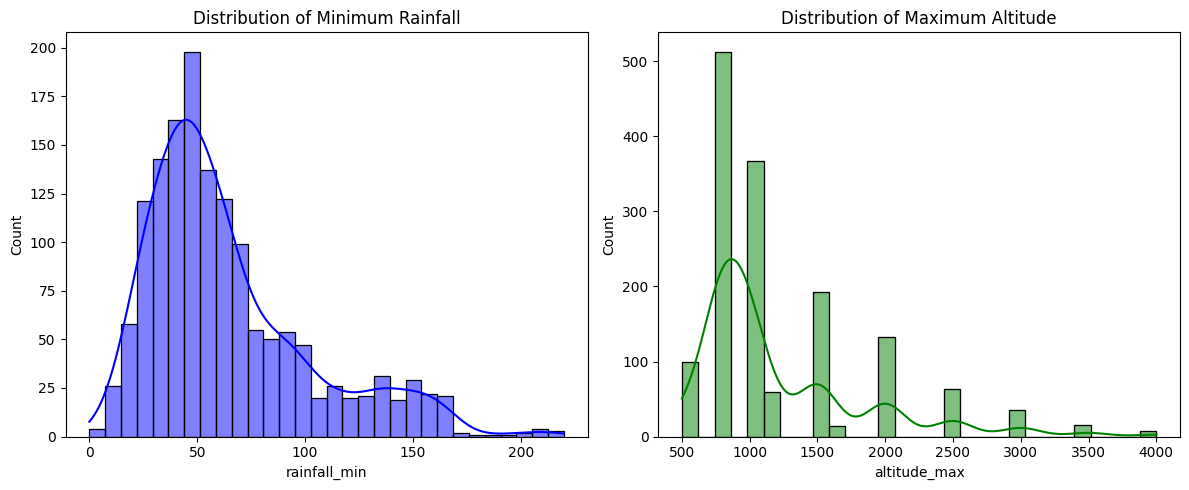

In [ ]:
# Visualize the distribution of some key features
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['rainfall_min'], kde=True, color='blue')
plt.title('Distribution of Minimum Rainfall')

plt.subplot(1, 2, 2)
sns.histplot(df['altitude_max'], kde=True, color='green')
plt.title('Distribution of Maximum Altitude')

plt.tight_layout()
plt.show()

# CREATE FEATURE MATRIX

In [ ]:
feature_cols = []

for col in available_categorical:
    if col != 'crop_name':
        feature_cols.append(col + '_encoded')

for col in available_numerical:
    if col in df.columns:
        feature_cols.append(col)

print(f"Total features for training: {len(feature_cols)}")
print(f"Feature list: {feature_cols}")

X = df[feature_cols]
y = df['crop_encoded']

X = X.fillna(X.mean())

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

Total features for training: 22
Feature list: ['soil_type_encoded', 'season_encoded', 'water_need_encoded', 'difficulty_level_encoded', 'country_encoded', 'location_field_encoded', 'temp_min', 'temp_max', 'ph_min', 'ph_max', 'rainfall_min', 'rainfall_max', 'duration_days', 'humidity_min', 'humidity_max', 'altitude_min', 'altitude_max', 'fertilizer_n', 'fertilizer_p', 'fertilizer_k', 'yield_ton_per_ha', 'profit_usd_per_ha']
X shape: (1500, 22)
y shape: (1500,)


# Splitting the Data

In [ ]:
# Define Features (X) and Target (y)
# We select features that a farmer would typically know or a sensor would provide
features = [
    'soil_type_encoded', 'temp_min', 'temp_max', 'ph_min', 'ph_max',
    'rainfall_min', 'rainfall_max', 'altitude_min', 'altitude_max',
    'location_field_encoded'
]

X = df[features]
y = df['crop_encoded']

# Split into 80% Training and 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Training crops: {len(y_train.unique())}")
print(f"Testing crops: {len(y_test.unique())}")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training samples: 1200
Testing samples: 300
Training crops: 110
Testing crops: 110


# Training the RANDOM FOREST Model

In [ ]:
# Scale numerical features
print("Scaling numerical features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Random Forest Model
print("Training Random Forest Classifier...")
rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)
print("Model training finished!")

y_pred_train = rf_model.predict(X_train_scaled)
y_pred_test = rf_model.predict(X_test_scaled)

train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Testing Accuracy: {test_accuracy * 100:.2f}%")

Scaling numerical features...
Training Random Forest Classifier...
Model training finished!
Training Accuracy: 99.00%
Testing Accuracy: 76.00%


# CROSS VALIDATION

In [ ]:
print("Performing 5-fold cross-validation...")
cv_scores = cross_val_score(rf_model, X_train_scaled, y_train, cv=5)
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV score: {cv_scores.mean() * 100:.2f}%")
print(f"Standard deviation: {cv_scores.std() * 100:.2f}%")

print("\n[11] Classification Report on Test Set:")
print(classification_report(y_test, y_pred, target_names=crop_encoder.classes_))

Performing 5-fold cross-validation...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


Cross-validation scores: [0.75416667 0.75       0.75833333 0.75416667 0.75833333]
Mean CV score: 75.50%
Standard deviation: 0.31%

[11] Classification Report on Test Set:
                    precision    recall  f1-score   support

            Almond       1.00      1.00      1.00         3
             Apple       1.00      1.00      1.00         2
   Apple (Mustang)       1.00      1.00      1.00         3
           Apricot       1.00      1.00      1.00         2
         Areca Nut       1.00      1.00      1.00         3
            Banana       1.00      1.00      1.00         2
            Barley       1.00      1.00      1.00         4
   Barnyard Millet       1.00      1.00      1.00         4
          Beetroot       0.00      0.00      0.00         2
      Bitter Gourd       0.00      0.00      0.00         2
        Black Gram       0.00      0.00      0.00         2
      Black Pepper       1.00      1.00      1.00         3
      Bottle Gourd       1.00      0.67      0.8

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#Feature Importance

Top 20 Most Important Features:
                  Feature  Importance
6            rainfall_max    0.169832
8            altitude_max    0.133657
1                temp_min    0.132200
2                temp_max    0.117071
7            altitude_min    0.104670
3                  ph_min    0.095286
5            rainfall_min    0.091969
4                  ph_max    0.091121
9  location_field_encoded    0.035484
0       soil_type_encoded    0.028711


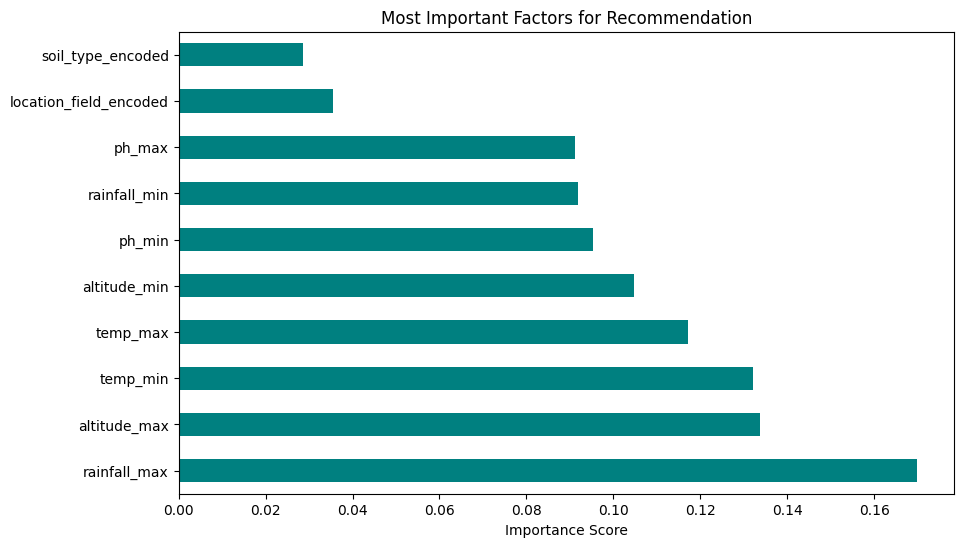

In [ ]:
print("Top 20 Most Important Features:")
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance.head(20))

# Plot Feature Importance
plt.figure(figsize=(10, 6))
importances = pd.Series(rf_model.feature_importances_, index=features)
importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Most Important Factors for Recommendation')
plt.xlabel('Importance Score')
plt.show()

# GRADIENT BOOSTING FOR COMPARISON

In [ ]:
print("Training Gradient Boosting Classifier for comparison...")
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

gb_model.fit(X_train_scaled, y_train)
gb_pred = gb_model.predict(X_test_scaled)
gb_accuracy = accuracy_score(y_test, gb_pred)

print(f"Gradient Boosting Accuracy: {gb_accuracy * 100:.2f}%")

# Calculate Random Forest test accuracy for comparison
test_accuracy = accuracy_score(y_test, y_pred)

if gb_accuracy > test_accuracy:
    best_model = gb_model
    print("\nGradient Boosting performs better. Using this as final model.")
else:
    best_model = rf_model
    print("\nRandom Forest performs better. Using this as final model.")

Training Gradient Boosting Classifier for comparison...
Gradient Boosting Accuracy: 71.00%

Random Forest performs better. Using this as final model.


# SAVE MODEL AND ENCODERS

In [ ]:
print("Saving model and encoders...")

joblib.dump(best_model, 'crop_model_final.pkl')
print("Saved: crop_model_final.pkl")

joblib.dump(crop_encoder, 'crop_encoder.pkl')
print("Saved: crop_encoder.pkl")

for col_name, encoder in encoders.items():
    joblib.dump(encoder, f'{col_name}_encoder.pkl')
    print(f"Saved: {col_name}_encoder.pkl")

joblib.dump(scaler, 'scaler.pkl')
print("Saved: scaler.pkl")

joblib.dump(feature_cols, 'feature_columns.pkl')
print("Saved: feature_columns.pkl")

print("All files saved successfully!")

Saving model and encoders...
Saved: crop_model_final.pkl
Saved: crop_encoder.pkl
Saved: soil_type_encoder.pkl
Saved: season_encoder.pkl
Saved: water_need_encoder.pkl
Saved: difficulty_level_encoder.pkl
Saved: country_encoder.pkl
Saved: location_field_encoder.pkl
Saved: scaler.pkl
Saved: feature_columns.pkl
All files saved successfully!


# PREDICTION FUNCTION AND TESTING

In [ ]:
print("Testing prediction function with sample inputs...")

def predict_crop(soil_type, season, temperature, ph, rainfall):
    # Initialize a dictionary to hold the values for the 10 features expected by the model
    # The global 'features' list defines these 10 features and their order.
    input_values_map = {}

    # Populate direct numerical inputs
    input_values_map['temp_min'] = temperature
    input_values_map['temp_max'] = temperature
    input_values_map['ph_min'] = ph
    input_values_map['ph_max'] = ph
    input_values_map['rainfall_min'] = rainfall
    input_values_map['rainfall_max'] = rainfall

    # Encode soil_type
    try:
        input_values_map['soil_type_encoded'] = encoders['soil_type'].transform([soil_type])[0]
    except ValueError:
        # Fallback if soil_type is not recognized by the encoder
        input_values_map['soil_type_encoded'] = 0 # Default to 0, assuming it's a safe representation for 'unknown'

    # Fill in the remaining features (altitude_min, altitude_max, location_field_encoded)
    # These are part of the model's 10 features but not direct function arguments.
    # Use means for numerical and a default (e.g., 0) for encoded categorical if not specified.
    input_values_map['altitude_min'] = df['altitude_min'].mean()
    input_values_map['altitude_max'] = df['altitude_max'].mean()

    # For location_field_encoded, since it's not provided, use a default (0)
    # This assumes 0 is a reasonable default for an unspecified location field.
    input_values_map['location_field_encoded'] = 0

    # Create the final feature vector in the precise order expected by the scaler.
    # The global 'features' variable (`['soil_type_encoded', 'temp_min', 'temp_max', 'ph_min', 'ph_max',
    #  'rainfall_min', 'rainfall_max', 'altitude_min', 'altitude_max', 'location_field_encoded']`)
    # defines this order and set of features.
    final_features_vector = [input_values_map[f_name] for f_name in features]

    # Convert to DataFrame with feature names to avoid the UserWarning
    features_df = pd.DataFrame([final_features_vector], columns=features)
    features_scaled = scaler.transform(features_df)
    prediction = best_model.predict(features_scaled)[0]
    crop_name = crop_encoder.inverse_transform([prediction])[0]

    probabilities = best_model.predict_proba(features_scaled)[0]
    confidence = max(probabilities)

    return crop_name, confidence

test_cases = [
    ("Loamy", "Monsoon", 28, 6.5, 150),
    ("Sandy", "Summer", 32, 6.8, 80),
    ("Clay", "Winter", 18, 7.0, 60),
    ("Silty", "Spring", 25, 6.5, 100),
    ("Black", "Summer", 30, 7.2, 70)
]

print("\nTest Predictions:")
print("-" * 60)
for soil, season, temp, ph, rain in test_cases:
    crop, conf = predict_crop(soil, season, temp, ph, rain)
    print(f"Soil: {soil:8} | Season: {season:8} | Temp: {temp:2} | pH: {ph:.1f} | Rain: {rain:3} -> Crop: {crop:20} | Confidence: {conf*100:.1f}%")
print("-" * 60)

Testing prediction function with sample inputs...

Test Predictions:
------------------------------------------------------------
Soil: Loamy    | Season: Monsoon  | Temp: 28 | pH: 6.5 | Rain: 150 -> Crop: Cotton               | Confidence: 19.3%
Soil: Sandy    | Season: Summer   | Temp: 32 | pH: 6.8 | Rain:  80 -> Crop: Cotton               | Confidence: 20.7%
Soil: Clay     | Season: Winter   | Temp: 18 | pH: 7.0 | Rain:  60 -> Crop: Wheat (Winter)       | Confidence: 20.5%
Soil: Silty    | Season: Spring   | Temp: 25 | pH: 6.5 | Rain: 100 -> Crop: Cotton               | Confidence: 20.7%
Soil: Black    | Season: Summer   | Temp: 30 | pH: 7.2 | Rain:  70 -> Crop: Cotton               | Confidence: 20.7%
------------------------------------------------------------


# FINAL SUMMARY

In [ ]:
print("TRAINING COMPLETE - SUMMARY REPORT")
print("=" * 60)
print(f"Total samples in dataset: {len(df)}")
print(f"Total unique crops: {len(crop_encoder.classes_)}")
print(f"Total features used: {len(feature_cols)}")
print(f"Final model accuracy: {test_accuracy * 100:.2f}%")
print(f"Cross-validation score: {cv_scores.mean() * 100:.2f}%")
print(f"Model saved as: crop_model_final.pkl")
print("=" * 60)

TRAINING COMPLETE - SUMMARY REPORT
Total samples in dataset: 1500
Total unique crops: 110
Total features used: 22
Final model accuracy: 76.00%
Cross-validation score: 75.50%
Model saved as: crop_model_final.pkl
